# Чекпоинт 5. Улучшение моделей

### План
1. Определить тематику поста с помощью лучшей модели
2. Применить кластеризацию к постам из одной тематики
3. Выбрать посты, которые будут предложены пользователю

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from collections import Counter
from typing import Iterable

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering, HDBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics.pairwise import cosine_distances
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import PCA

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from data_utils import (
    clean_text, preprocess_data, calc_metrics, extract_ngrams, find_templates,
    remove_templates, clean_templates_in_df
)
from cluster_utils import (
    get_X_2d, plot_clusters_2d, plot_cluster_centroids_with_texts, plot_clusters_3d,
    plot_cluster_channel_heatmap, get_X_3d, plot_clusters_3d_matplotlib, draw_cluster_sizes,
    get_top_texts_per_cluster, get_cluster_density
)

import nltk
from nltk.corpus import stopwords
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

RANDOM_STATE = 42

In [3]:
try:
    nltk.download('punkt')
    nltk.download('stopwords')
except:
    pass

russian_stopwords = set(stopwords.words('russian'))
print(russian_stopwords)

{'ни', 'был', 'без', 'впрочем', 'и', 'только', 'лучше', 'какая', 'были', 'об', 'этом', 'разве', 'почти', 'ты', 'вам', 'нет', 'тут', 'их', 'этот', 'ведь', 'совсем', 'тогда', 'эту', 'будет', 'нее', 'нас', 'на', 'над', 'было', 'после', 'всегда', 'будто', 'или', 'за', 'да', 'них', 'теперь', 'уже', 'тем', 'про', 'по', 'конечно', 'ее', 'потому', 'ним', 'при', 'тебя', 'ж', 'больше', 'так', 'вы', 'то', 'сейчас', 'а', 'можно', 'может', 'она', 'моя', 'чтоб', 'же', 'что', 'ему', 'все', 'здесь', 'вдруг', 'никогда', 'два', 'мне', 'там', 'себя', 'о', 'но', 'много', 'наконец', 'под', 'в', 'уж', 'ничего', 'более', 'от', 'кто', 'тоже', 'куда', 'надо', 'другой', 'эти', 'опять', 'вас', 'перед', 'вот', 'ли', 'всех', 'мой', 'бы', 'им', 'если', 'меня', 'чем', 'быть', 'хорошо', 'через', 'какой', 'к', 'хоть', 'ей', 'него', 'еще', 'нельзя', 'ну', 'свою', 'не', 'этого', 'всю', 'зачем', 'во', 'для', 'сам', 'всего', 'себе', 'между', 'я', 'такой', 'где', 'чего', 'они', 'нибудь', 'была', 'его', 'том', 'этой', 'ней'

[nltk_data] Downloading package punkt to /home/maleksyuk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/maleksyuk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Загрузка и предобработка данных

In [4]:
# df = pd.read_csv('../data/all_channels_combined.csv')
df = pd.read_csv('../aggregate_bot_modules/data/raw_posts_labeled.csv')
df = preprocess_data(df)
df.head()

[*] Строк после удаления пустых текстов: 11200
[*] Очищаем тексты...
[*] Убрали слишком короткие тексты: 11200 → 11159


,id,date,channel,topic,text,text_clean
0,144954,2026-03-11T16:20:30+00:00,@rbc_news,economy,**Ответственность за атаку на начальную школу ...,ответственность за атаку на начальную школу в ...
1,144953,2026-03-11T16:20:24+00:00,@rbc_news,economy,Банковский финансовый мониторинг становится бо...,банковский финансовый мониторинг становится бо...
2,144952,2026-03-11T16:10:42+00:00,@rbc_news,economy,🎙 Прямо сейчас в эфире Радио РБК — **связь все...,прямо сейчас в эфире радио рбк связь все еще р...
3,144951,2026-03-11T15:59:30+00:00,@rbc_news,economy,🔵[Олимпийский комитет России станет владельцем...,олимпийский комитет россии станет владельцем г...
4,144950,2026-03-11T15:44:01+00:00,@rbc_news,economy,"Бывший помощник главы государства, экс-замести...",бывший помощник главы государства экс заместит...


In [5]:
def width_print(text, width=80):
    curr = 0
    while curr < len(text):
        print(text[curr:curr+width])
        curr += width

index = 0
width_print(df["text_clean"][index])

ответственность за атаку на начальную школу в иранском минабе лежит на сша сообщ
ает the new york times nyt со ссылкой на американских чиновников и других лиц зн
акомых с предварительными данными расследования здание начальной школы попало по
д удар из за ошибки в прицеливании американских военных они наносили удары по со
седней иранской базе частью которой ранее было здание этой школы показало предва
рительное расследование офицеры центрального командования сша определили координ
аты цели удара используя устаревшие данные предоставленные агентством оборонной 
разведки сообщили лица знакомые с расследованием чиновники подчеркнули что вывод
ы являются предварительными по их словам еще есть ряд вопросов на которые нужно 
ответить в том числе почему устаревшая информация не была перепроверена канал рб
к в max приложение рбк для ios и android


In [6]:
channels = df['channel'].unique()
channel = channels[2]

In [7]:
df = clean_templates_in_df(df)
df.head()

,id,date,channel,topic,text,text_clean,text_clean2
0,144954,2026-03-11T16:20:30+00:00,@rbc_news,economy,**Ответственность за атаку на начальную школу ...,ответственность за атаку на начальную школу в ...,ответственность за атаку на начальную школу в ...
1,144953,2026-03-11T16:20:24+00:00,@rbc_news,economy,Банковский финансовый мониторинг становится бо...,банковский финансовый мониторинг становится бо...,банковский финансовый мониторинг становится бо...
2,144952,2026-03-11T16:10:42+00:00,@rbc_news,economy,🎙 Прямо сейчас в эфире Радио РБК — **связь все...,прямо сейчас в эфире радио рбк связь все еще р...,прямо сейчас в эфире радио рбк связь все еще р...
3,144951,2026-03-11T15:59:30+00:00,@rbc_news,economy,🔵[Олимпийский комитет России станет владельцем...,олимпийский комитет россии станет владельцем г...,олимпийский комитет россии станет владельцем г...
4,144950,2026-03-11T15:44:01+00:00,@rbc_news,economy,"Бывший помощник главы государства, экс-замести...",бывший помощник главы государства экс заместит...,бывший помощник главы государства экс заместит...


### Определение тематики

В проекте будем сначала определять тематику поста, затем посты из одной тематики разбивать на подгруппы с помощью кластеризации. Воспользуемся моделью, которая показала лучшие результаты в предыдущих чекпоинтах

In [8]:
X_data = df["text_clean2"]
y_data = df["topic"]
X_extra = df[['date', 'channel', 'topic']]

X_train_text, X_test_text, \
y_train_topic, y_test_topic, \
X_extra_train, X_extra_test \
    = train_test_split(X_data, y_data, X_extra, test_size=0.3, random_state=RANDOM_STATE)

X_data = df["text_clean2"]
y_data = df["topic"]

In [9]:
X_train_text.shape

(7734,)

In [10]:
extra_stopwords = ["это", "подписаться"]

stopwords_list = list(russian_stopwords)
stopwords_list.extend(extra_stopwords)

In [11]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),    # 1-2 граммы
    min_df=5,              # слово должно встретиться минимум в 5 документах
    max_features=20000,    # максимум 20к признаков
    stop_words=stopwords_list
)
tfidf.fit(X_train_text)
X_train = tfidf.transform(X_train_text)
X_test = tfidf.transform(X_test_text)

le = LabelEncoder()
y_train = le.fit_transform(y_train_topic)
y_test = le.transform(y_test_topic)

print(f"({len(le.classes_)}) классов: {list(le.classes_)}")
print(f"Распределение классов в train:")
unique, counts = np.unique(y_train, return_counts=True)
for cls_idx, count in zip(unique, counts):
    cls_name = le.inverse_transform([cls_idx])[0]
    print(f"    {cls_name} (idx={cls_idx}): {count} примеров")

(5) классов: ['economy', 'it', 'politics', 'science', 'sport']
Распределение классов в train:
    economy (idx=0): 1893 примеров
    it (idx=1): 1640 примеров
    politics (idx=2): 2545 примеров
    science (idx=3): 1005 примеров
    sport (idx=4): 651 примеров


In [12]:
base_model = MultinomialNB(alpha=0.1)
base_model.fit(X_train, y_train)

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


In [13]:
calc_metrics(y_test, base_model.predict(X_test))

{'f1_macro': 0.8308902772682785,
 'accuracy': 0.8144796380090498,
 'precision_macro': 0.8377900092349414,
 'recall_macro': 0.8273152335399241}

### Кластеризация текстов одной тематики

In [14]:
y_train_topic.unique()

array(['it', 'economy', 'science', 'politics', 'sport'], dtype=object)

Зафиксируем одну тематику. Далее будем работать с текстами этой тематики. Подготовим данные

In [15]:
topic = y_train_topic.unique()[4]
topic

'sport'

In [16]:
df_topic = df[df['topic'] == topic]

X_topic_data = df_topic["text_clean2"]
X_topic_extra = df_topic[['date', 'channel', 'topic']]

In [17]:
tfidf_topic = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_features=20000,
    stop_words=stopwords_list
)
X_topic_tfidf = tfidf_topic.fit_transform(X_topic_data)

In [19]:
X_for_clustering = X_topic_tfidf.toarray()

# Эти объекты понадобятся далее для визуализации
X_for_2d = get_X_2d(X_for_clustering)
X_for_3d = get_X_3d(X_for_clustering)

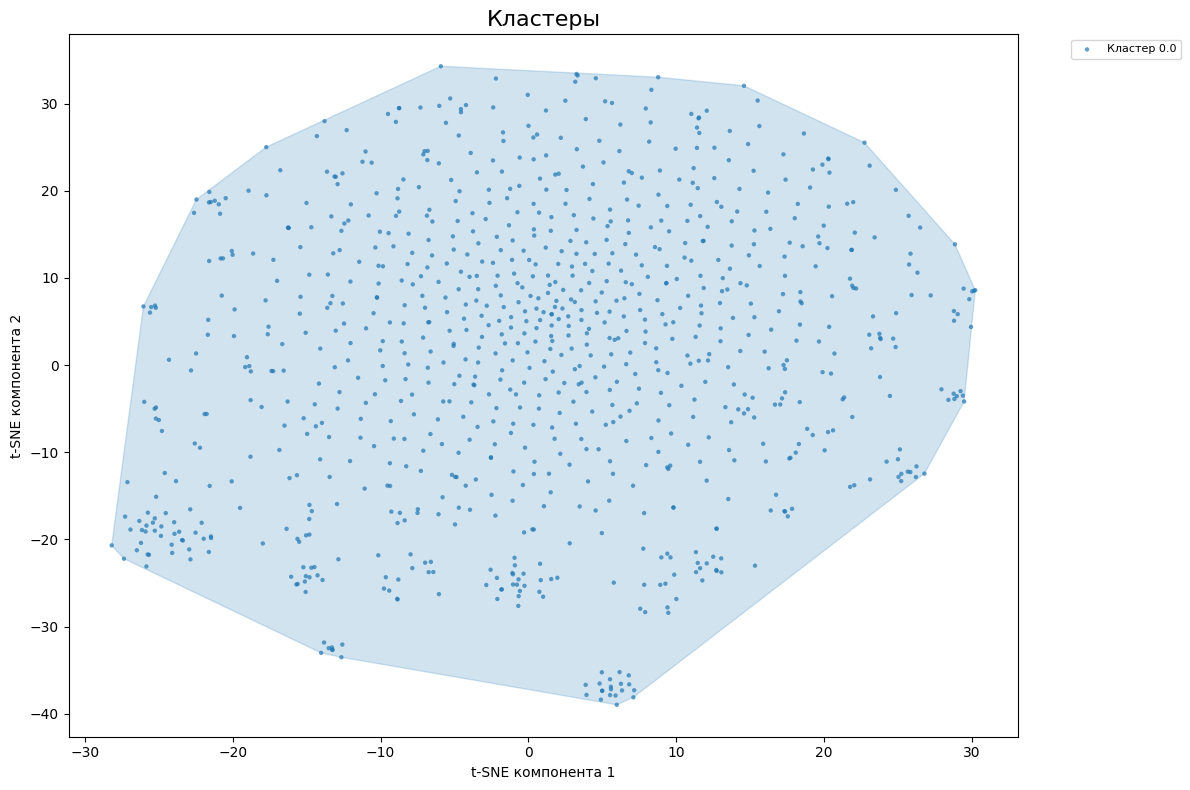

In [20]:
zero_labels = np.zeros((X_for_clustering.shape[0],))
plot_clusters_2d(X_for_clustering, zero_labels, X_for_2d)

In [34]:
def print_top_of_clusters(top_texts: dict, density: dict | None = None):
    cluster_ids = density.keys() if density is not None else top_texts.keys()
    for cluster_id in cluster_ids:
        density_value = density[cluster_id] if density else -1
        if density_value >= 0 and density_value < 1e-4:
            density_text = f' (плотность: 0)'
        else:
            density_text = f' (плотность: {density_value:.4f})' if density else ''
        
        texts_with_dist = top_texts[cluster_id]
        
        print(f"Кластер {cluster_id:.0f}{density_text}:")
        for text, dist in texts_with_dist:
            print(f"  {dist:.4f}: {text[:150]}...")
        print()


top_texts = get_top_texts_per_cluster(X_topic_data, zero_labels, X_for_clustering)
print_top_of_clusters(top_texts)

Кластер 0:
  0.7212: илья малинин после провала на олимпиаде я облажался лучший канал о фигурном катании...
  0.7225: газета new york times не пожалела илью малинина и поместила фото падения американца на олимпиаде на целую страницу с заголовком пал бог квадов лучший ...
  0.7312: аделия петросян точно без медали на олимпиаде в милане россия впервые за лет без наград в фигурном катании на играх лучший канал о фигурном катании...



В дальнейшем будем перебирать гиперпараметры моделей и смотреть на метрики `silhouette_score` (о внутреннем состоянии кластеров; чем ближе к 1, тем лучше) и `davies_bouldin_score` (применяют к текстам; лучше, если будет меньше 1). В функции ниже реализован перебор.

In [83]:
def not_grid_search(model, data, n_clusters: Iterable | None = None,
                    eps_list: Iterable | None = None, min_samples_list: Iterable | None = None,
                    min_cluster_size_list: Iterable | None = None, metric: str = 'cosine'):
        
    scorers = {
        'silhouette_score': silhouette_score,
        'davies_bouldin_score': davies_bouldin_score
    }

    results = []

    def add_scores(result, clusters_topic):
        for scorer_name, scorer in scorers.items():
            result[scorer_name] = scorer(data, clusters_topic)

    def print_result(result: dict):
        items = [f'{key}={value:.4f}' for key, value in result.items()]
        print(' '.join(items))

    def create_and_print_result(result: dict):
        add_scores(result, clusters_topic)
        print_result(result)
        results.append(result)

    if n_clusters is not None:
        for n in n_clusters:
            try:
                estimator = model(n_clusters=n, random_state=RANDOM_STATE)
            except:
                estimator = model(n_clusters=n)
            clusters_topic = estimator.fit_predict(data)
            create_and_print_result({
                'n_clusters': n
            })

    elif eps_list is not None and min_samples_list is not None:
        for eps in eps_list:
            for min_samples in min_samples_list:
                estimator = model(eps=eps, min_samples=min_samples, metric=metric)
                clusters_topic = estimator.fit_predict(data)
                n_clusters_dbscan = len(set(clusters_topic)) - (1 if -1 in clusters_topic else 0)
                if n_clusters_dbscan > 1:
                    create_and_print_result({
                        'eps': eps,
                        'min_samples': min_samples,
                        'n_clusters': n_clusters_dbscan
                    })

    elif min_cluster_size_list is not None:
        for min_cluster_size in min_cluster_size_list:
            if min_samples_list is None:
                min_samples_list = [None]
            for min_samples in min_samples_list:
                estimator = model(min_cluster_size=min_cluster_size, min_samples=min_samples, metric=metric)
                clusters_topic = estimator.fit_predict(data)
                n_clusters_hdbscan = len(set(clusters_topic)) - (1 if -1 in clusters_topic else 0)
                if n_clusters_hdbscan > 1:
                    result = {
                        'min_cluster_size': min_cluster_size,
                        'n_clusters': n_clusters_hdbscan
                    }
                    if min_samples is not None:
                        result['min_samples'] = min_samples
                    create_and_print_result(result)

    return results

#### KMeans

Подберём количество кластеров и построим графики

In [23]:
best_kmeans = not_grid_search(KMeans, X_for_clustering, np.arange(2, 150, 8))

n_clusters=2.0000 silhouette_score=0.0055 davies_bouldin_score=9.3510
n_clusters=10.0000 silhouette_score=0.0261 davies_bouldin_score=6.5672
n_clusters=18.0000 silhouette_score=0.0331 davies_bouldin_score=5.8912
n_clusters=26.0000 silhouette_score=0.0423 davies_bouldin_score=5.0227
n_clusters=34.0000 silhouette_score=0.0456 davies_bouldin_score=4.7404
n_clusters=42.0000 silhouette_score=0.0485 davies_bouldin_score=4.4806
n_clusters=50.0000 silhouette_score=0.0470 davies_bouldin_score=4.2874
n_clusters=58.0000 silhouette_score=-0.0306 davies_bouldin_score=1.5933
n_clusters=66.0000 silhouette_score=-0.0325 davies_bouldin_score=1.5681
n_clusters=74.0000 silhouette_score=-0.0314 davies_bouldin_score=1.5936
n_clusters=82.0000 silhouette_score=-0.0319 davies_bouldin_score=1.5708
n_clusters=90.0000 silhouette_score=-0.0317 davies_bouldin_score=1.5475
n_clusters=98.0000 silhouette_score=-0.0359 davies_bouldin_score=1.4938
n_clusters=106.0000 silhouette_score=-0.0367 davies_bouldin_score=1.4910

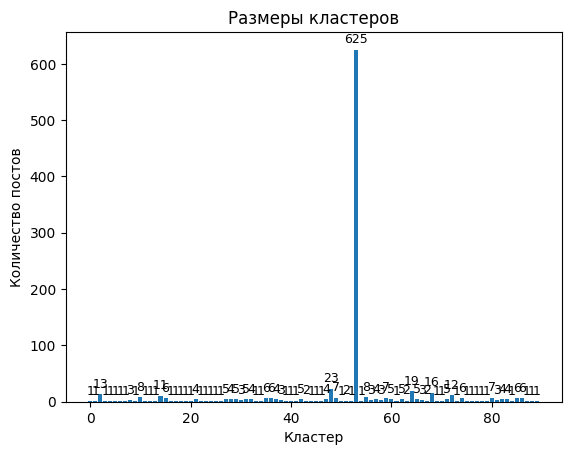

In [24]:
kmeans_topic = KMeans(n_clusters=90, random_state=RANDOM_STATE)
clusters_kmeans_topic = kmeans_topic.fit_predict(X_for_clustering)

draw_cluster_sizes(clusters_kmeans_topic)

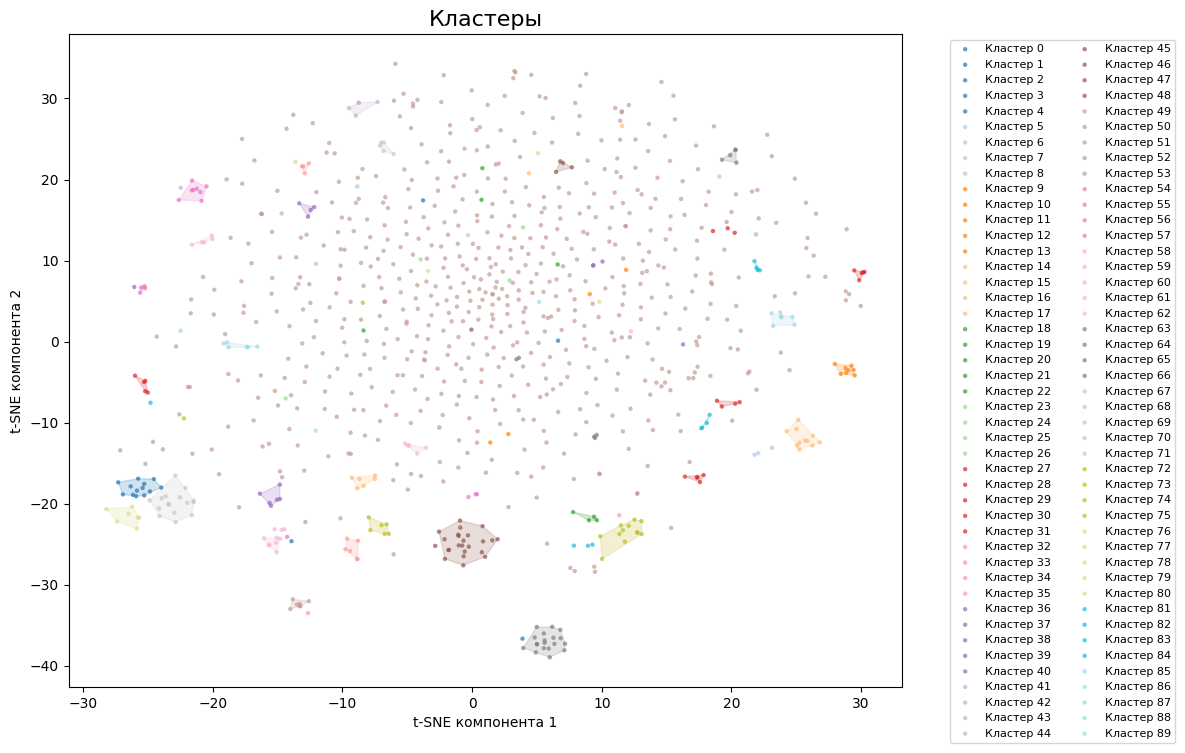

In [25]:
plot_clusters_2d(X_for_clustering, clusters_kmeans_topic, X_for_2d)

In [35]:
top_clusters_texts_ = get_top_texts_per_cluster(X_topic_data, clusters_kmeans_topic, X_for_clustering)
top_clusters_density = get_cluster_density(X_for_clustering, clusters_kmeans_topic)

print_top_of_clusters(top_clusters_texts_, top_clusters_density)

Кластер 0 (плотность: 0):
  0.0000: боруссия снова без победы в дер класикер кейн сделал дубль а решил исход матча гол киммиха...

Кластер 1 (плотность: 0):
  0.0000: финальный медальный зачет олимпиады в милане на этих играх нам запомнится тотальная доминация сборной норвегии итальянцы в последний день уступили сво...

Кластер 3 (плотность: 0):
  0.0000: бразильский гонщик кайо коллет выложил анонс первого этапа индикара который пройдет в санкт петербурге штат флорида на картинке изображены исаакиевски...

Кластер 4 (плотность: 0):
  0.0000: российский футбол возвращается с зимних каникул в честь этого winline выпустил новый ролик и объявил о запуске бота winline матч тура где болельщики н...

Кластер 5 (плотность: 0):
  0.0000: винисиус выложил заявление в соцсетях после скандального матча с бенфикой расисты это прежде всего трусы им нужно прикрывать рот футболкой чтобы показ...

Кластер 6 (плотность: 0):
  0.0000: бавария дежурно разобралась с гладбахом дома мюнхенцы добились шестой

Некоторые кластеры очень даже хорошо собрались в группы. Тексты в этих кластерах достаточно близки друг к другу по смыслу

#### Hierarchy

In [37]:
best_hierarchical = not_grid_search(AgglomerativeClustering, X_for_clustering, np.arange(2, 300, 12))

n_clusters=2.0000 silhouette_score=0.0100 davies_bouldin_score=2.6373
n_clusters=14.0000 silhouette_score=0.0291 davies_bouldin_score=3.6897
n_clusters=26.0000 silhouette_score=0.0407 davies_bouldin_score=3.7547
n_clusters=38.0000 silhouette_score=0.0472 davies_bouldin_score=3.3554
n_clusters=50.0000 silhouette_score=0.0547 davies_bouldin_score=3.5661
n_clusters=62.0000 silhouette_score=0.0551 davies_bouldin_score=3.3953
n_clusters=74.0000 silhouette_score=0.0607 davies_bouldin_score=3.2202
n_clusters=86.0000 silhouette_score=0.0659 davies_bouldin_score=3.0915
n_clusters=98.0000 silhouette_score=0.0689 davies_bouldin_score=2.9521
n_clusters=110.0000 silhouette_score=0.0733 davies_bouldin_score=2.8275
n_clusters=122.0000 silhouette_score=0.0773 davies_bouldin_score=2.7394
n_clusters=134.0000 silhouette_score=0.0804 davies_bouldin_score=2.5998
n_clusters=146.0000 silhouette_score=0.0831 davies_bouldin_score=2.5181
n_clusters=158.0000 silhouette_score=0.0861 davies_bouldin_score=2.4476
n_

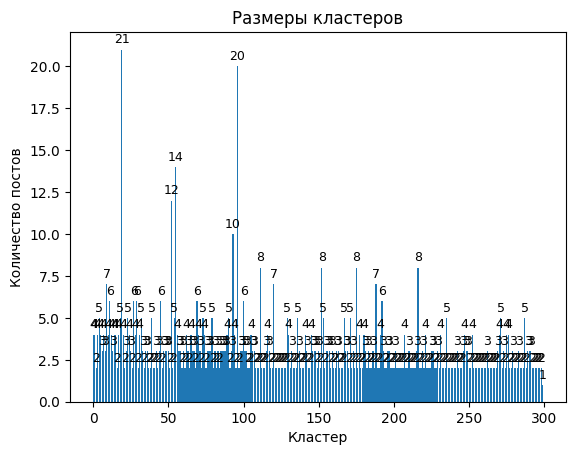

CPU times: user 1.79 s, sys: 238 ms, total: 2.03 s
Wall time: 1.77 s


In [38]:
%%time

hierarchical_topic = AgglomerativeClustering(n_clusters=300)
clusters_hier_topic = hierarchical_topic.fit_predict(X_for_clustering)

draw_cluster_sizes(clusters_hier_topic)

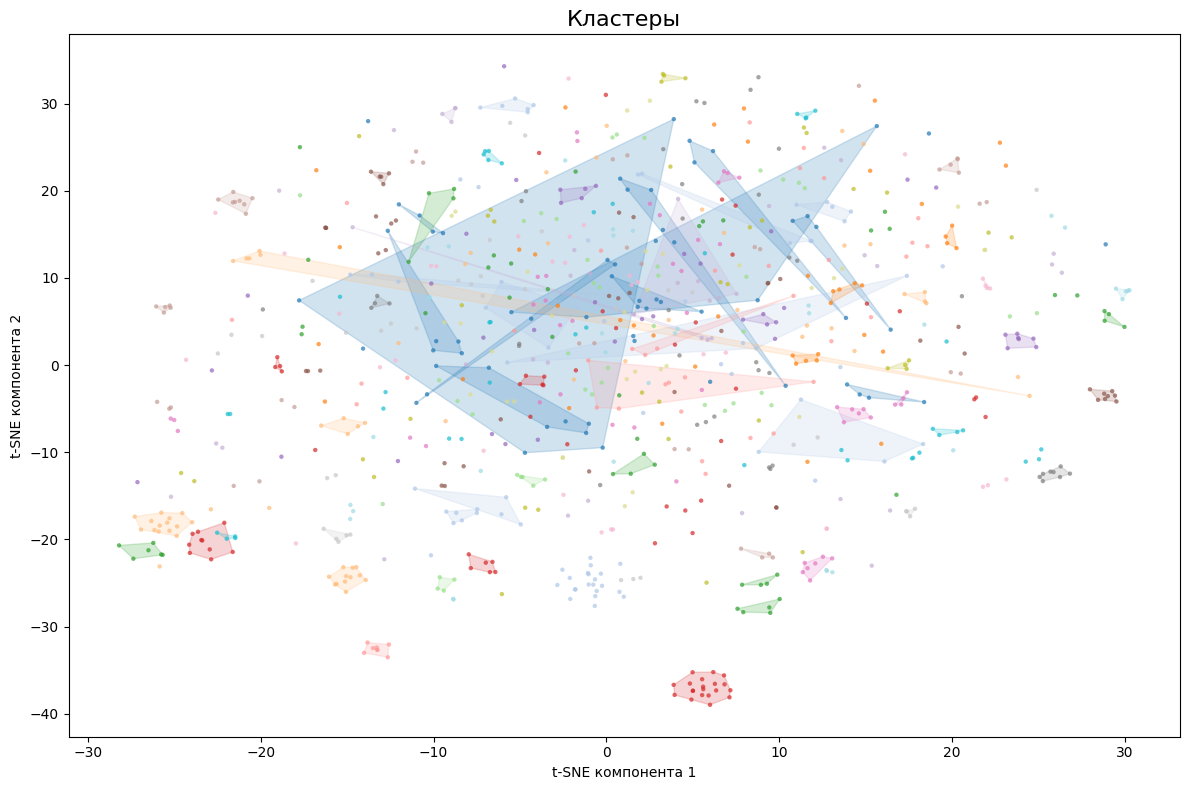

In [40]:
plot_clusters_2d(X_for_clustering, clusters_hier_topic, X_for_2d, add_legend=False)

In [ ]:
# plot_clusters_3d_matplotlib(X_for_3d, clusters_hier_topic)

In [41]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_hier_topic, X_for_clustering),
    get_cluster_density(X_for_clustering, clusters_hier_topic)
)

Кластер 299 (плотность: 0):
  0.0000: кто то загрузил в приложение для киноманов letterboxd фейковую страничку байопика о криштину роналду в котором португальца должен сыграть тимати шалам...

Кластер 209 (плотность: 0.0255):
  0.0255: если случится полная блокировка телеграма и другого выбора не останется вот все наши каналы в max не призываем подписываться сейчас просто запомните э...
  0.0255: если случится полная блокировка телеграма и другого выбора не останется вот все наши каналы в max не призываем подписываться прямо сейчас просто запом...

Кластер 161 (плотность: 0.0268):
  0.0268: результаты розыгрыша победитель архип проверить результаты...
  0.0268: результаты розыгрыша победитель антон проверить результаты...

Кластер 264 (плотность: 0.0654):
  0.0654: матвей сафонов выйдет в старте псж на матч против ренна это четвертая игра россиянина в основе подряд вновь не пропустит...
  0.0654: матвей сафонов в свой день рождения выйдет в старте псж на матч против монако это седьмая 

Визуально эта кластеризация работает плохо. Хотя глядя на тексты в получившихся кластерах, топ текстов близок друг к другу.

####  DBSCAN

In [42]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X_for_clustering)

In [49]:
from sklearn.preprocessing import normalize
X_norm = normalize(X_for_clustering)

In [ ]:
best_dbscan = not_grid_search(
    DBSCAN, X_scaled,
    eps_list=np.arange(0.1, 1, 0.1), min_samples_list=np.arange(2, 10, 1)
)

eps=0.1000 min_samples=2.0000 n_clusters=4.0000 silhouette_score=-0.1576 davies_bouldin_score=1.4220
eps=0.2000 min_samples=2.0000 n_clusters=16.0000 silhouette_score=-0.1399 davies_bouldin_score=1.3889
eps=0.2000 min_samples=3.0000 n_clusters=6.0000 silhouette_score=-0.1489 davies_bouldin_score=1.5111
eps=0.2000 min_samples=4.0000 n_clusters=3.0000 silhouette_score=-0.0197 davies_bouldin_score=1.4398
eps=0.3000 min_samples=2.0000 n_clusters=32.0000 silhouette_score=-0.1197 davies_bouldin_score=1.4775
eps=0.3000 min_samples=3.0000 n_clusters=10.0000 silhouette_score=-0.1380 davies_bouldin_score=1.5920
eps=0.3000 min_samples=4.0000 n_clusters=3.0000 silhouette_score=0.0053 davies_bouldin_score=1.7177
eps=0.3000 min_samples=5.0000 n_clusters=3.0000 silhouette_score=0.0053 davies_bouldin_score=1.7177
eps=0.3000 min_samples=6.0000 n_clusters=2.0000 silhouette_score=-0.0106 davies_bouldin_score=1.7100
eps=0.3000 min_samples=7.0000 n_clusters=2.0000 silhouette_score=-0.0106 davies_bouldin_sc

In [ ]:
best_dbscan = not_grid_search(
    DBSCAN, X_norm,
    eps_list=np.arange(0.1, 1, 0.1), min_samples_list=np.arange(2, 10, 1),
    metric='euclidean'
)

eps=0.5000 min_samples=2.0000 n_clusters=8.0000 silhouette_score=-0.2784 davies_bouldin_score=2.7828
eps=0.6000 min_samples=2.0000 n_clusters=10.0000 silhouette_score=-0.2724 davies_bouldin_score=2.5565
eps=0.6000 min_samples=3.0000 n_clusters=2.0000 silhouette_score=-0.0119 davies_bouldin_score=1.4693
eps=0.7000 min_samples=2.0000 n_clusters=22.0000 silhouette_score=-0.2544 davies_bouldin_score=2.0025
eps=0.7000 min_samples=3.0000 n_clusters=6.0000 silhouette_score=-0.0175 davies_bouldin_score=1.5489
eps=0.7000 min_samples=4.0000 n_clusters=2.0000 silhouette_score=0.0031 davies_bouldin_score=1.6186
eps=0.8000 min_samples=2.0000 n_clusters=32.0000 silhouette_score=-0.2305 davies_bouldin_score=1.9414
eps=0.8000 min_samples=3.0000 n_clusters=12.0000 silhouette_score=-0.0153 davies_bouldin_score=1.7196
eps=0.8000 min_samples=4.0000 n_clusters=6.0000 silhouette_score=-0.0069 davies_bouldin_score=1.8073
eps=0.8000 min_samples=5.0000 n_clusters=3.0000 silhouette_score=0.0021 davies_bouldin_s

DBSCAN нашел 12 кластеров + шум


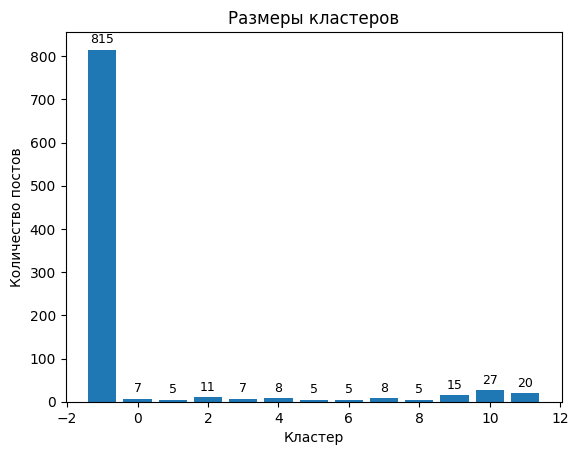

CPU times: user 503 ms, sys: 233 ms, total: 736 ms
Wall time: 312 ms


In [79]:
# metric = 'cosine'
# X_dbscan = X_scaled
# eps = 0.5
# min_samples = 3

metric = 'euclidean'
X_dbscan = X_norm
eps = 0.95
min_samples = 5

dbscan_topic = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
clusters_dbscan_topic = dbscan_topic.fit_predict(X_dbscan)
n_clusters_dbscan = len(set(clusters_dbscan_topic)) - (1 if -1 in clusters_dbscan_topic else 0)

print(f"DBSCAN нашел {n_clusters_dbscan} кластеров{' + шум' if -1 in clusters_dbscan_topic else ' без шума'}")

draw_cluster_sizes(clusters_dbscan_topic)

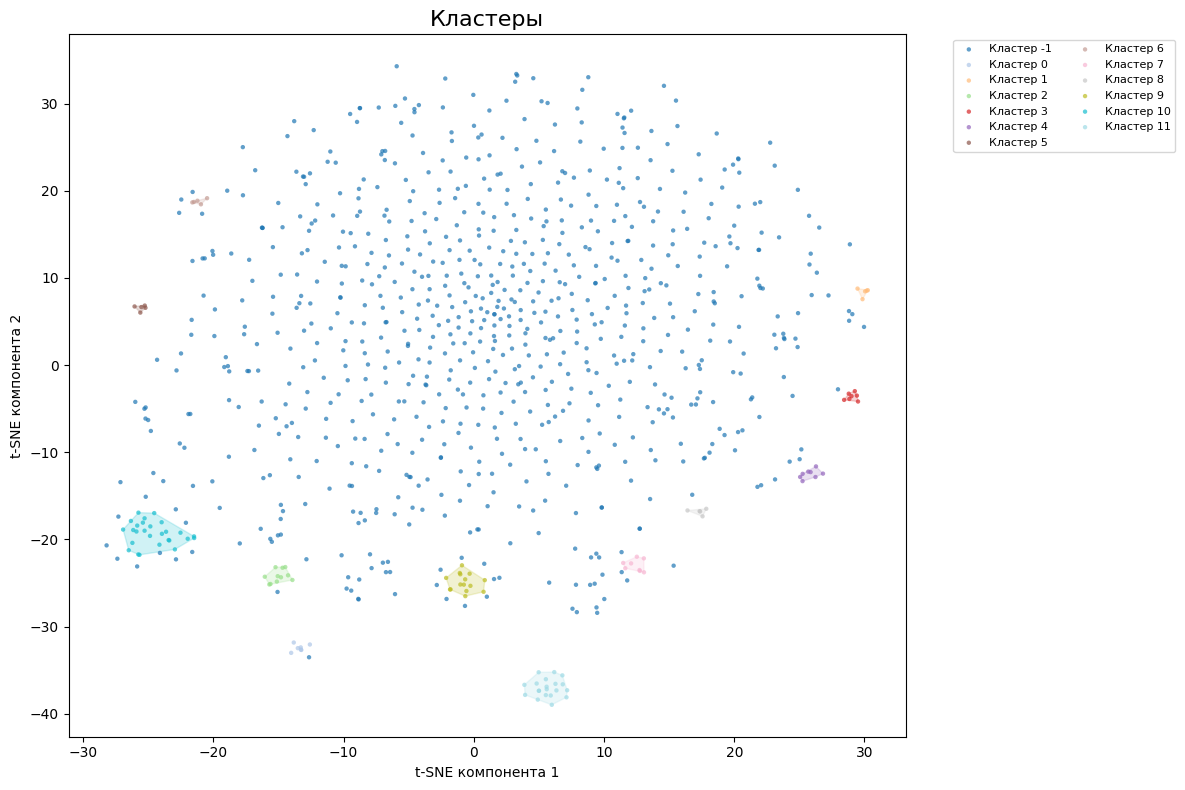

In [80]:
plot_clusters_2d(X_for_clustering, clusters_dbscan_topic, X_for_2d)

In [81]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_dbscan_topic, X_for_clustering),
    get_cluster_density(X_for_clustering, clusters_dbscan_topic)
)

Кластер 1 (плотность: 0.1580):
  0.0919: лапорта парализовал работу рынка в барселоне кандидат в президенты барсы станцевал за рулем подъемника под громкие овации грузчиков как же он сияет...
  0.1252: кандидат в президенты барсы жоан лапорта весело прыгал на трибуне под заряд кто не скачет тот мадридиста во время матча с вильярреалом и показал кому ...
  0.1343: кандидат в президенты барсы фонт настойчиво пытался потрогать лапорту во время дебатов в ответ жоан погладил его по руке а потом оба посмеялись...

Кластер 0 (плотность: 0.1617):
  0.0908: во вьетнаме на курорте нячанг вместо скачек ставят на заплывы обезьян народу эта забава собирает не меньше чем матчи фнл grinynrv a канал о поп культу...
  0.1010: якутский любитель counter strike под ником kant ka комментирует и стримит матчи своей любимой команды hotu на улице сейчас в республике саха канал о п...
  0.1232: великобритания выбрала того кто представит страну на евровидении в этом году это музыкант под псевдонимом look mum no

Для этой модели полученные метрики при переборе параметров не дали понимания, что лучше использовать. Поэтому подбор происходил визуально по графику кластеров. В полученных кластерах топ текстов также близок друг к другу

#### HDBSCAN

In [87]:
best_hdbscan = not_grid_search(HDBSCAN, X_scaled, min_cluster_size_list=np.arange(2, 15, 2))

min_cluster_size=2.0000 n_clusters=218.0000 silhouette_score=0.0177 davies_bouldin_score=2.1265
min_cluster_size=4.0000 n_clusters=40.0000 silhouette_score=-0.0140 davies_bouldin_score=2.8776
min_cluster_size=6.0000 n_clusters=13.0000 silhouette_score=-0.0077 davies_bouldin_score=3.2205
min_cluster_size=8.0000 n_clusters=8.0000 silhouette_score=-0.0116 davies_bouldin_score=3.1967
min_cluster_size=10.0000 n_clusters=6.0000 silhouette_score=-0.0426 davies_bouldin_score=3.1610
min_cluster_size=12.0000 n_clusters=3.0000 silhouette_score=-0.0383 davies_bouldin_score=3.2806
min_cluster_size=14.0000 n_clusters=2.0000 silhouette_score=-0.0529 davies_bouldin_score=2.6949


In [86]:
%%time
best_hdbscan = not_grid_search(HDBSCAN, X_norm, min_cluster_size_list=np.arange(2, 15, 2), metric='euclidean')

min_cluster_size=2.0000 n_clusters=68.0000 silhouette_score=-0.1826 davies_bouldin_score=2.0066
min_cluster_size=4.0000 n_clusters=11.0000 silhouette_score=0.0042 davies_bouldin_score=2.1607
min_cluster_size=6.0000 n_clusters=6.0000 silhouette_score=-0.0002 davies_bouldin_score=2.3415
min_cluster_size=8.0000 n_clusters=3.0000 silhouette_score=-0.0125 davies_bouldin_score=2.2731
min_cluster_size=10.0000 n_clusters=2.0000 silhouette_score=-0.0173 davies_bouldin_score=2.3534
min_cluster_size=12.0000 n_clusters=2.0000 silhouette_score=-0.0221 davies_bouldin_score=2.1743
CPU times: user 22.8 s, sys: 4.73 s, total: 27.5 s
Wall time: 22 s


HDBSCAN нашел 68 кластеров + шум


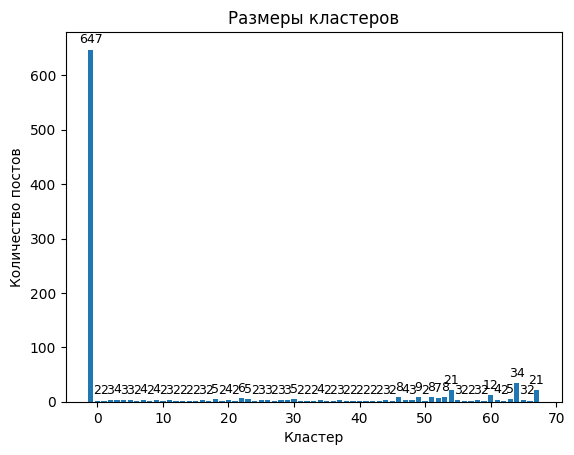

In [ ]:
# metric = 'cosine'
# X_hdbscan = X_scaled
# min_cluster_size = 

metric = 'euclidean'
X_hdbscan = X_norm
min_cluster_size = 2

hdbscan_topic = HDBSCAN(min_cluster_size=min_cluster_size, metric=metric)
clusters_hdbscan_topic = hdbscan_topic.fit_predict(X_hdbscan)
n_clusters_hdbscan = len(set(clusters_hdbscan_topic)) - (1 if -1 in clusters_hdbscan_topic else 0)

print(f"HDBSCAN нашел {n_clusters_hdbscan} кластеров{' + шум' if -1 in clusters_hdbscan_topic else ' без шума'}")

draw_cluster_sizes(clusters_hdbscan_topic)

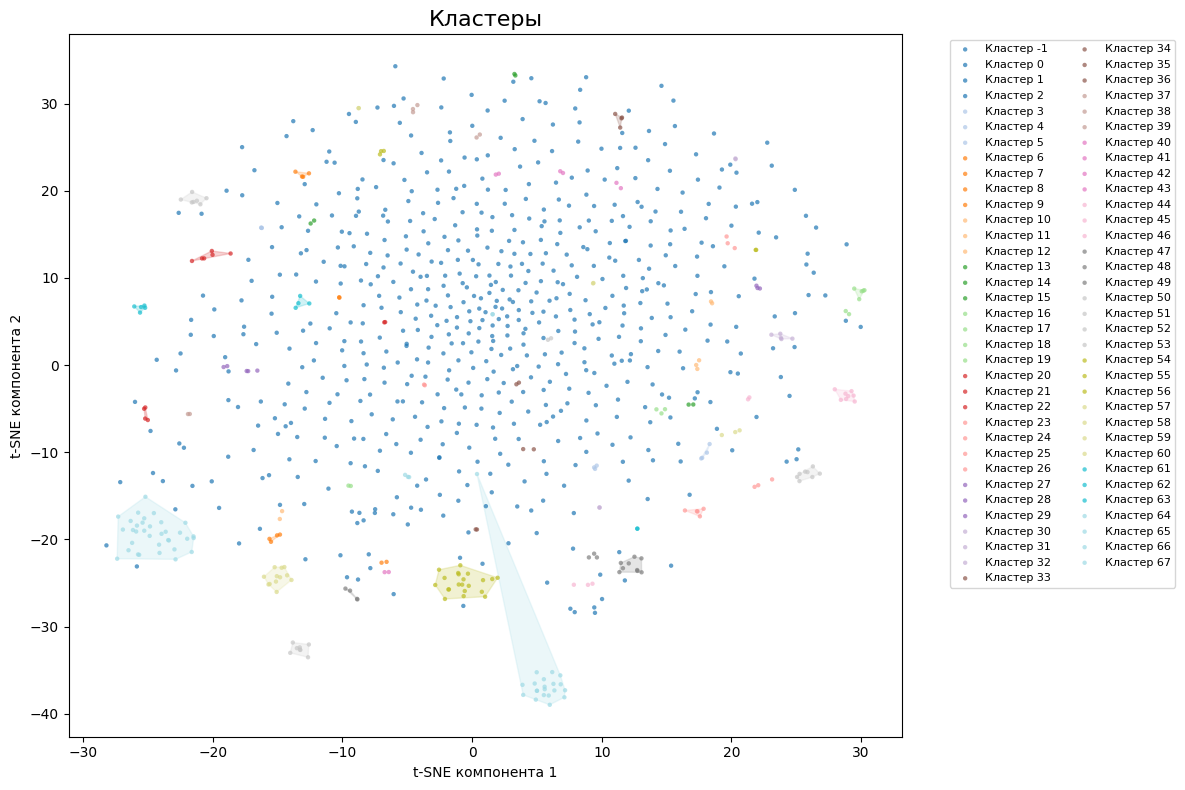

In [89]:
plot_clusters_2d(X_for_clustering, clusters_hdbscan_topic, X_for_2d)

In [90]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_hdbscan_topic, X_for_clustering),
    get_cluster_density(X_for_clustering, clusters_hdbscan_topic)
)

Кластер 62 (плотность: 0.0255):
  0.0255: если случится полная блокировка телеграма и другого выбора не останется вот все наши каналы в max не призываем подписываться сейчас просто запомните э...
  0.0255: если случится полная блокировка телеграма и другого выбора не останется вот все наши каналы в max не призываем подписываться прямо сейчас просто запом...

Кластер 31 (плотность: 0.0268):
  0.0268: результаты розыгрыша победитель архип проверить результаты...
  0.0268: результаты розыгрыша победитель антон проверить результаты...

Кластер 24 (плотность: 0.0595):
  0.0595: андрес иньеста станет спортивным директором сборной марокко накануне из команды уволили валида реграги выводившего ее в полуфинал чм фабрицио романо м...
  0.0595: зидан станет тренером сборной франции после чм с зинедином достигнуто устное соглашение фабрицио романо наконец то...

Кластер 56 (плотность: 0.0654):
  0.0654: матвей сафонов выйдет в старте псж на матч против ренна это четвертая игра россиянина в основе 

#### Спектральная кластеризация

In [93]:
n_samples = min(5000, X_for_clustering.shape[0])
X_sample = X_for_clustering[:n_samples]

pca = PCA(n_components=150, random_state=RANDOM_STATE)
X_reduced = pca.fit_transform(X_sample)

print(f"После PCA: {X_reduced.shape}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

После PCA: (938, 150)
Объясненная дисперсия: 57.58%


In [94]:
%%time
best_spectral = not_grid_search(SpectralClustering, X_reduced, np.arange(2, 150, 8))

n_clusters=2.0000 silhouette_score=0.0616 davies_bouldin_score=1.8426
n_clusters=10.0000 silhouette_score=0.0805 davies_bouldin_score=2.4755
n_clusters=18.0000 silhouette_score=0.0789 davies_bouldin_score=3.1310
n_clusters=26.0000 silhouette_score=0.0907 davies_bouldin_score=3.1019
n_clusters=34.0000 silhouette_score=0.0979 davies_bouldin_score=2.8657
n_clusters=42.0000 silhouette_score=0.1123 davies_bouldin_score=2.5284
n_clusters=50.0000 silhouette_score=0.1148 davies_bouldin_score=2.6483
n_clusters=58.0000 silhouette_score=0.1143 davies_bouldin_score=2.4391
n_clusters=66.0000 silhouette_score=0.1260 davies_bouldin_score=2.4218
n_clusters=74.0000 silhouette_score=0.1275 davies_bouldin_score=2.3498
n_clusters=82.0000 silhouette_score=0.1267 davies_bouldin_score=2.2768
n_clusters=90.0000 silhouette_score=0.1309 davies_bouldin_score=2.2208
n_clusters=98.0000 silhouette_score=0.1347 davies_bouldin_score=2.2091
n_clusters=106.0000 silhouette_score=0.1369 davies_bouldin_score=2.1482
n_clus

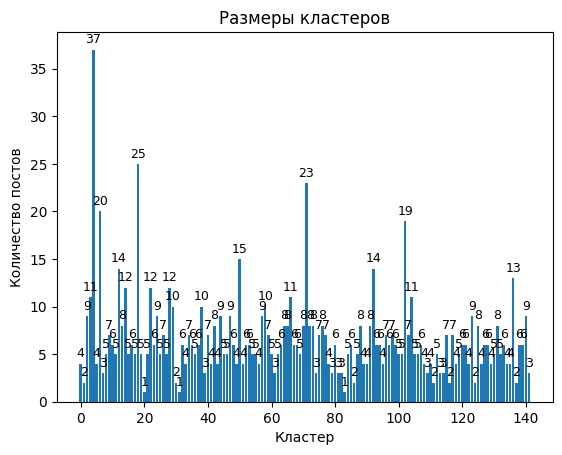

In [101]:
spectral_topic = SpectralClustering(n_clusters=142, random_state=RANDOM_STATE)
clusters_spectral_topic = spectral_topic.fit_predict(X_reduced)

draw_cluster_sizes(clusters_spectral_topic)

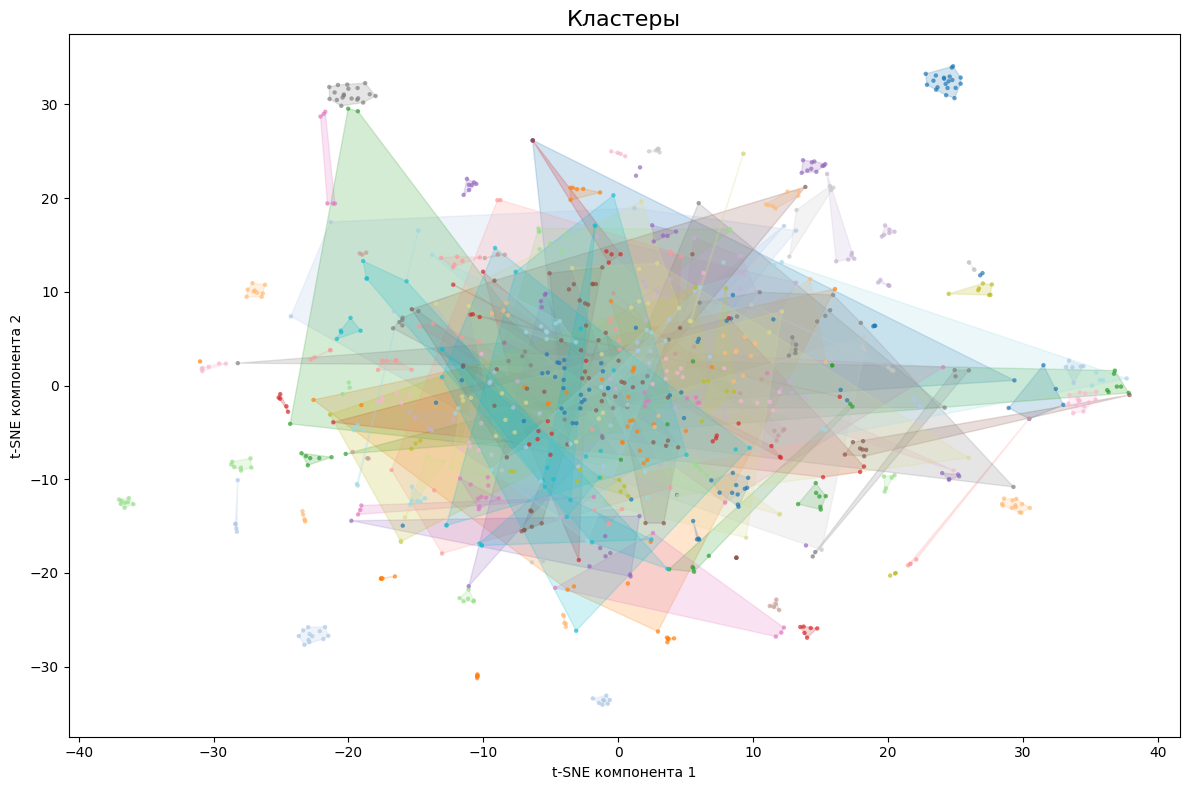

In [ ]:
plot_clusters_2d(X_reduced, clusters_spectral_topic, add_legend=False)

In [103]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_spectral_topic, X_for_clustering),
    get_cluster_density(X_for_clustering, clusters_spectral_topic)
)

Кластер 20 (плотность: 0):
  0.0000: ватерполистки венгерского клуба uvse в самой концовке матча лиги чемпионов обыграли соперниц из олимпиакоса и отпраздновали победу вместе с фанатами...

Кластер 31 (плотность: 0):
  0.0000: кто хозяин сан сиро выберите победителя самого яркого дерби выходных голосовать...

Кластер 83 (плотность: 0):
  0.0000: генеральный менеджер сиэтла джон шнайдер бросал в толпу фигурки с надписью иисус любит тебя на параде после победы в супербоуле шнайдер набожный катол...

Кластер 30 (плотность: 0.0268):
  0.0268: результаты розыгрыша победитель архип проверить результаты...
  0.0268: результаты розыгрыша победитель антон проверить результаты...

Кластер 7 (плотность: 0.1080):
  0.0662: сборная россии сыграет с мали и гватемалой марта в краснодаре и марта в санкт петербурге mash на спорте...
  0.1050: сборная россии сыграет с мали в санкт петербурге марта малийцы дошли до финала последнего кубка африки где уступили будущим чемпионам из сенегала...
  0.1529: сбо

Визуально эта модель очень плохо выделила кластеры. Хотя в топе текстов также присутствуют сильные совпадения  между собой.

### Добавим признаки

Попробуем добавить время, некоторые параметры текста (например, длина).

In [104]:
X_extra_for_clustering = X_topic_extra

In [196]:
def extract_temporal_features(date_feature):
    date_feature = pd.to_datetime(date_feature)
    
    features = {
        'hour': date_feature.dt.hour,
        'day_of_week': date_feature.dt.dayofweek
    }
    
    return features

In [197]:
X_datetime = extract_temporal_features(X_extra_for_clustering['date'])
X_datetime = pd.DataFrame(X_datetime)
X_datetime

,hour,day_of_week
6007,16,2
6008,15,2
6009,14,2
6010,13,2
6011,13,2
...,...,...
6995,8,4
6996,7,4
6997,6,4
6998,6,4


In [ ]:
def extract_structural_features(text_feature):
    features = {
        'len': text_feature.apply(len),
        'word_count': text_feature.apply(lambda x: len(x.split())),
        'question_marks': text_feature.apply(lambda x: x.count('?')),
        'exclamation_marks': text_feature.apply(lambda x: x.count('1')),
        'digit_ratio': text_feature.apply(
            lambda text: sum(1 for c in text if c.isdigit()) / max(1, len(text))
        )
    }
    return features

In [112]:
X_structure = extract_structural_features(X_topic_data)
X_structure = pd.DataFrame(X_structure)
X_structure

,len,word_count,question_marks,exclamation_marks,digit_ratio
6007,141,20,0,0,0.0
6008,105,20,0,0,0.0
6009,172,27,0,0,0.0
6010,423,70,0,0,0.0
6011,264,43,0,0,0.0
...,...,...,...,...,...
6995,278,39,0,0,0.0
6996,361,63,0,0,0.0
6997,293,43,0,0,0.0
6998,309,41,0,0,0.0


In [ ]:
X_combined = np.hstack([
    X_for_clustering,
    X_datetime,
    X_structure
])

In [114]:
X_combined.shape

(938, 869)

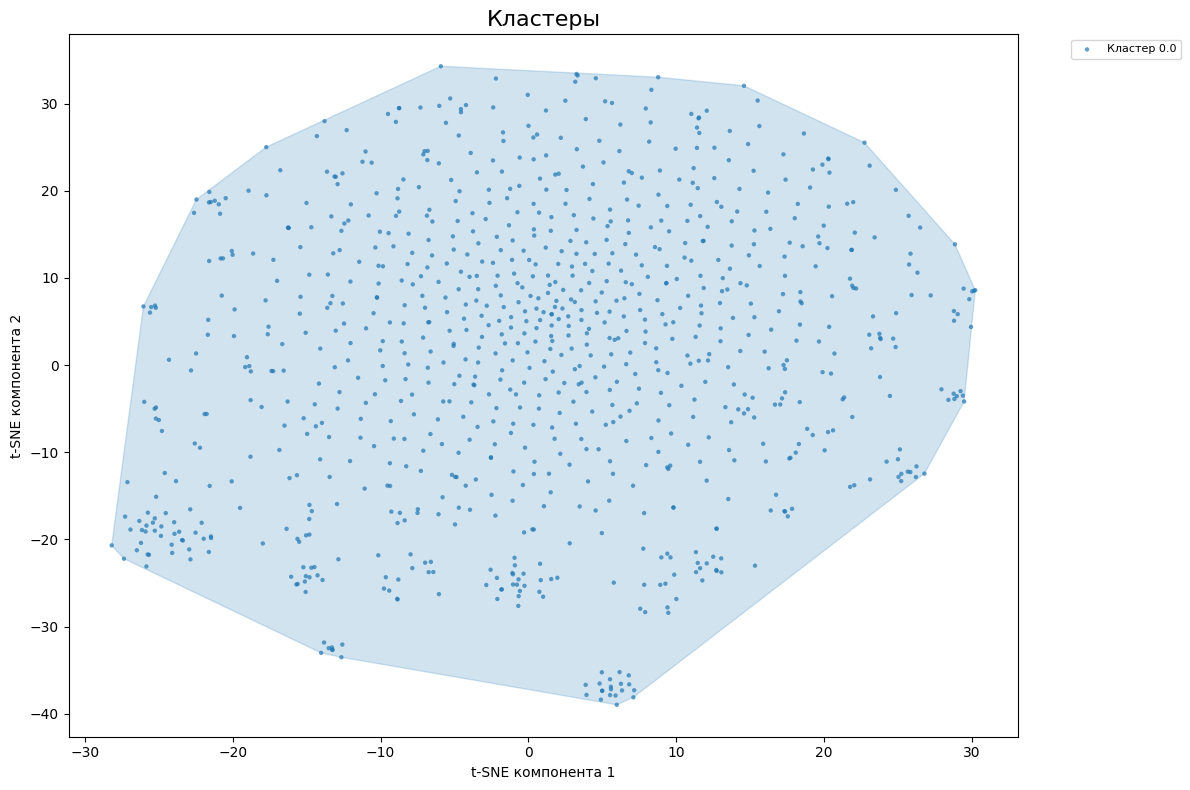

In [183]:
zero_labels_combined = np.zeros((X_combined.shape[0],))
plot_clusters_2d(X_combined, zero_labels_combined, X_for_2d)

### Повторим кластеризацию

#### KMeans

In [116]:
%%time

best_kmeans_extra = not_grid_search(KMeans, X_combined, np.arange(2, 150, 8))

n_clusters=2.0000 silhouette_score=0.9197 davies_bouldin_score=0.5282
n_clusters=10.0000 silhouette_score=0.4817 davies_bouldin_score=0.4559
n_clusters=18.0000 silhouette_score=0.4003 davies_bouldin_score=0.5435
n_clusters=26.0000 silhouette_score=0.3679 davies_bouldin_score=0.6400
n_clusters=34.0000 silhouette_score=0.3156 davies_bouldin_score=0.7662
n_clusters=42.0000 silhouette_score=0.3068 davies_bouldin_score=0.8521
n_clusters=50.0000 silhouette_score=0.2961 davies_bouldin_score=0.8657
n_clusters=58.0000 silhouette_score=0.2897 davies_bouldin_score=0.8805
n_clusters=66.0000 silhouette_score=0.2837 davies_bouldin_score=0.8868
n_clusters=74.0000 silhouette_score=0.2790 davies_bouldin_score=0.8942
n_clusters=82.0000 silhouette_score=0.2632 davies_bouldin_score=0.9464
n_clusters=90.0000 silhouette_score=0.2583 davies_bouldin_score=0.9724
n_clusters=98.0000 silhouette_score=0.2511 davies_bouldin_score=0.9750
n_clusters=106.0000 silhouette_score=0.2447 davies_bouldin_score=0.9942
n_clus

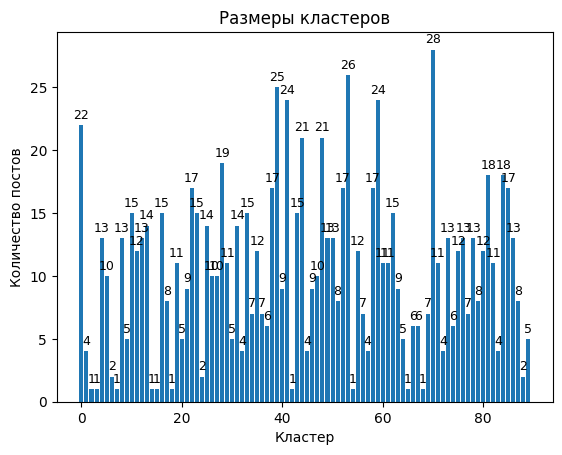

In [117]:
kmeans_topic_extra = KMeans(n_clusters=90, random_state=RANDOM_STATE)
clusters_kmeans_topic_extra = kmeans_topic_extra.fit_predict(X_combined)

draw_cluster_sizes(clusters_kmeans_topic_extra)

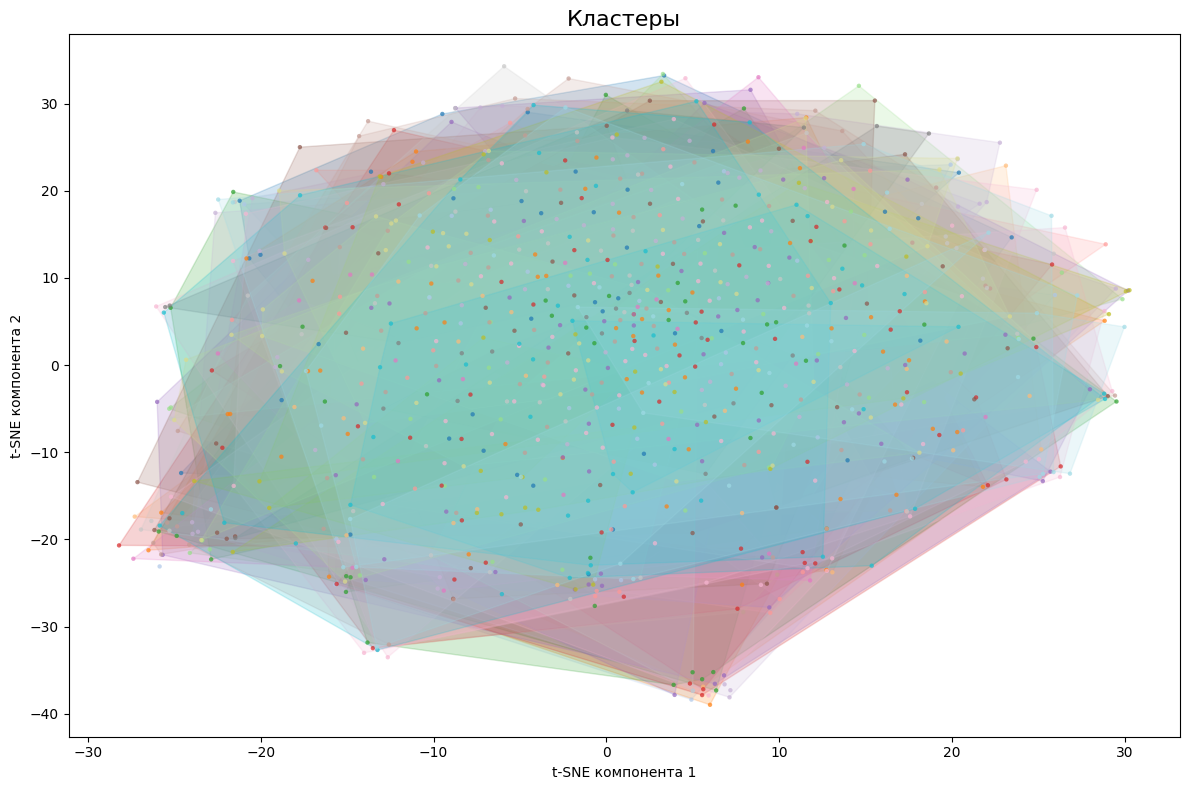

In [118]:
plot_clusters_2d(X_combined, clusters_kmeans_topic_extra, X_for_2d, add_legend=False)

In [119]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_kmeans_topic_extra, X_combined),
    get_cluster_density(X_combined, clusters_kmeans_topic_extra)
)

Кластер 2 (плотность: 0):
  0.0000: гвардиола предложил журналисту войти в свой штаб после максимально футбольного вопроса на пресс конференции перед матчем кубка англии я хотел бы напом...

Кластер 3 (плотность: 0):
  0.0000: официальное заявление цска по поводу жалобы краснодара на предмет расизма в сторону кордобы пфк цска категорически осуждает любые проявления расизма ц...

Кластер 7 (плотность: 0):
  0.0000: президент сельты написала открытое письмо мадонне она хочет отыскать футболку в которой певица выступала на их стадионе в году дорогая мадонна я пишу ...

Кластер 14 (плотность: 0):
  0.0000: пеп гвардиола блистательно ответил джиму рэтклиффу на слова о колонизации британии иммигрантами в своей речи совладелец мю перепутал все цифры и преув...

Кластер 15 (плотность: 0):
  0.0000: винисиус выложил заявление в соцсетях после скандального матча с бенфикой расисты это прежде всего трусы им нужно прикрывать рот футболкой чтобы показ...

Кластер 18 (плотность: 0):
  0.0000: красно

#### Hierarchy

In [120]:
%%time

_ = not_grid_search(AgglomerativeClustering, X_combined, np.arange(2, 300, 12))

n_clusters=2.0000 silhouette_score=0.9645 davies_bouldin_score=0.0238
n_clusters=14.0000 silhouette_score=0.4300 davies_bouldin_score=0.4530
n_clusters=26.0000 silhouette_score=0.3320 davies_bouldin_score=0.6368
n_clusters=38.0000 silhouette_score=0.2828 davies_bouldin_score=0.8149
n_clusters=50.0000 silhouette_score=0.2705 davies_bouldin_score=0.9086
n_clusters=62.0000 silhouette_score=0.2765 davies_bouldin_score=0.8848
n_clusters=74.0000 silhouette_score=0.2768 davies_bouldin_score=0.8783
n_clusters=86.0000 silhouette_score=0.2674 davies_bouldin_score=0.9149
n_clusters=98.0000 silhouette_score=0.2598 davies_bouldin_score=0.9390
n_clusters=110.0000 silhouette_score=0.2540 davies_bouldin_score=0.9644
n_clusters=122.0000 silhouette_score=0.2527 davies_bouldin_score=0.9616
n_clusters=134.0000 silhouette_score=0.2522 davies_bouldin_score=0.9602
n_clusters=146.0000 silhouette_score=0.2495 davies_bouldin_score=0.9525
n_clusters=158.0000 silhouette_score=0.2477 davies_bouldin_score=0.9413
n_

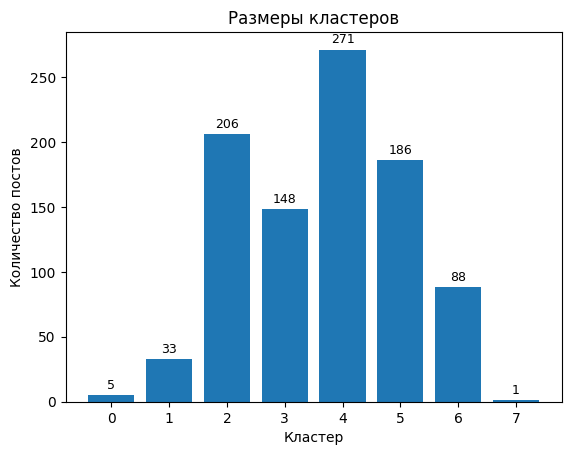

CPU times: user 1.04 s, sys: 206 ms, total: 1.25 s
Wall time: 1.01 s


In [132]:
%%time

hierarchical_topic_extra = AgglomerativeClustering(n_clusters=8)
clusters_hier_topic_extra = hierarchical_topic_extra.fit_predict(X_combined)

draw_cluster_sizes(clusters_hier_topic_extra)

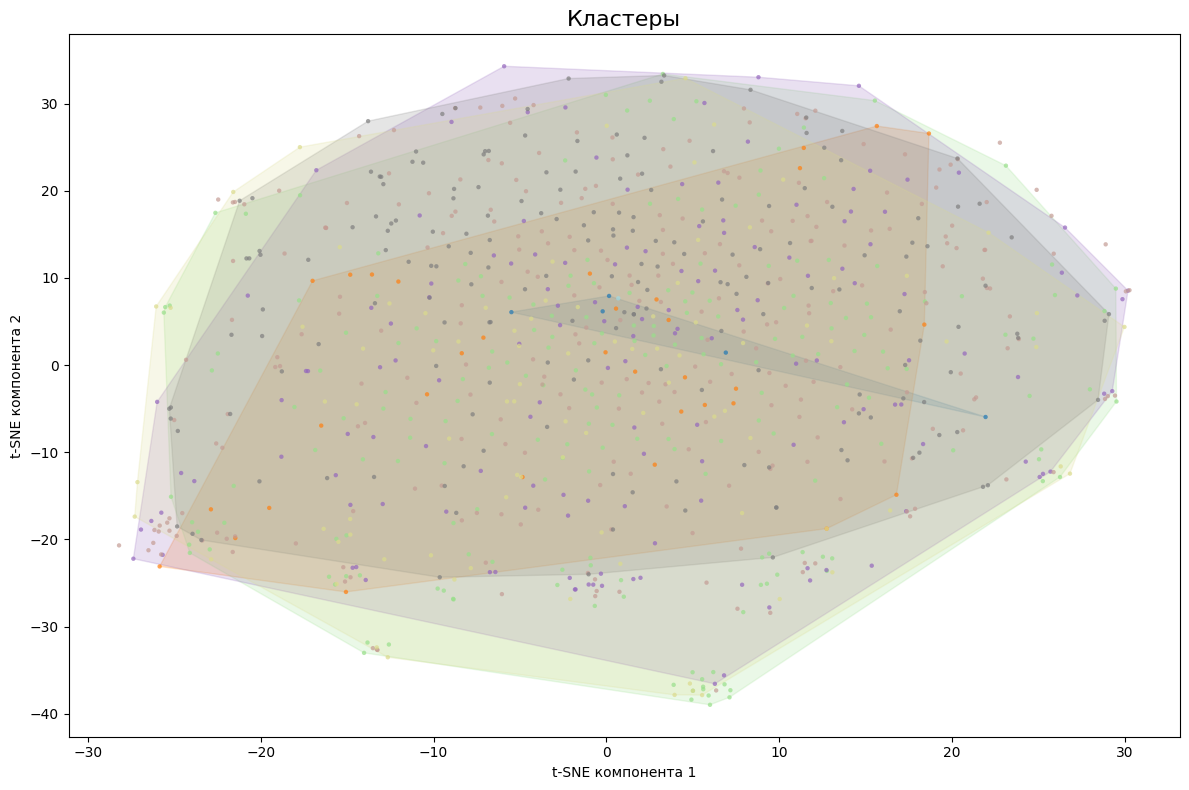

In [133]:
plot_clusters_2d(X_combined, clusters_hier_topic_extra, X_for_2d, add_legend=False)

In [135]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_hier_topic_extra, X_for_clustering),
    get_cluster_density(X_for_clustering, clusters_hier_topic_extra)
)

Кластер 7 (плотность: 0):
  0.0000: официальное заявление цска по поводу жалобы краснодара на предмет расизма в сторону кордобы пфк цска категорически осуждает любые проявления расизма ц...

Кластер 0 (плотность: 0.5124):
  0.4589: президент сельты написала открытое письмо мадонне она хочет отыскать футболку в которой певица выступала на их стадионе в году дорогая мадонна я пишу ...
  0.4969: гвардиола предложил журналисту войти в свой штаб после максимально футбольного вопроса на пресс конференции перед матчем кубка англии я хотел бы напом...
  0.5045: краснодар выступил с заявлением по итогам вчерашнего проигранного матча с цска когда вместо того чтобы обратить внимание на проявления расизма выражен...

Кластер 1 (плотность: 0.7548):
  0.6447: эмоции аделии петросян после первого выступления на олимпиаде в милане я настолько была спокойна что даже мама говорит ну ты как то это поволнуйся что...
  0.6731: петр гуменник после шестого места на олимпиаде я думаю будет возможность еще выс

#### DBSCAN

In [137]:
scaler_extra = StandardScaler(with_mean=False)
X_extra_scaled = scaler_extra.fit_transform(X_combined)
X_extra_norm = normalize(X_combined)

In [ ]:
%%time
_ = not_grid_search(
    DBSCAN, X_extra_scaled,
    eps_list=np.arange(0.1, 1, 0.1), min_samples_list=np.arange(2, 10, 1)
)

eps=0.1000 min_samples=2.0000 n_clusters=3.0000 silhouette_score=-0.0682 davies_bouldin_score=1.2217
eps=0.2000 min_samples=2.0000 n_clusters=15.0000 silhouette_score=-0.1402 davies_bouldin_score=1.3970
eps=0.2000 min_samples=3.0000 n_clusters=6.0000 silhouette_score=-0.1485 davies_bouldin_score=1.5201
eps=0.2000 min_samples=4.0000 n_clusters=3.0000 silhouette_score=-0.0196 davies_bouldin_score=1.4455
eps=0.3000 min_samples=2.0000 n_clusters=33.0000 silhouette_score=-0.1186 davies_bouldin_score=1.4872
eps=0.3000 min_samples=3.0000 n_clusters=10.0000 silhouette_score=-0.1377 davies_bouldin_score=1.6030
eps=0.3000 min_samples=4.0000 n_clusters=4.0000 silhouette_score=0.0062 davies_bouldin_score=1.6342
eps=0.3000 min_samples=5.0000 n_clusters=2.0000 silhouette_score=0.0030 davies_bouldin_score=1.8202
eps=0.3000 min_samples=6.0000 n_clusters=2.0000 silhouette_score=-0.0108 davies_bouldin_score=1.7158
eps=0.3000 min_samples=7.0000 n_clusters=2.0000 silhouette_score=-0.0108 davies_bouldin_sc

In [141]:
%%time
_ = not_grid_search(
    DBSCAN, X_extra_norm,
    eps_list=np.arange(0.1, 5, 0.3), min_samples_list=np.arange(2, 10, 1),
    metric='euclidean'
)

CPU times: user 37.5 s, sys: 118 ms, total: 37.6 s
Wall time: 9.62 s


DBSCAN нашел 12 кластеров + шум


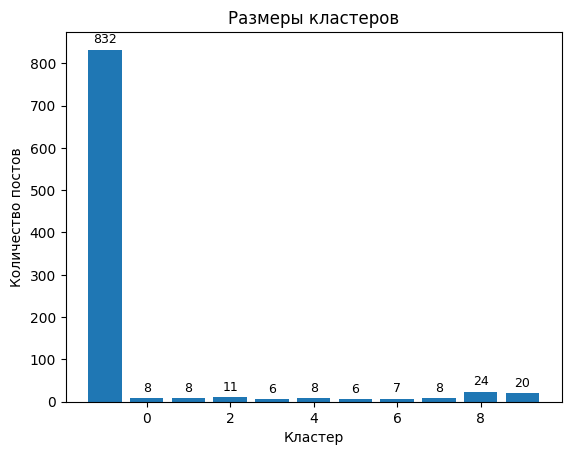

In [156]:
metric = 'cosine'
X_extra_dbscan = X_extra_scaled
eps = 0.5
min_samples = 6

# metric = 'euclidean'
# X_extra_dbscan = X_extra_norm
# eps = 0.95
# min_samples = 5

dbscan_topic_extra = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
clusters_dbscan_topic_extra = dbscan_topic_extra.fit_predict(X_extra_dbscan)
n_clusters_dbscan_extra = len(set(clusters_dbscan_topic_extra)) - (1 if -1 in clusters_dbscan_topic_extra else 0)

print(f"DBSCAN нашел {n_clusters_dbscan} кластеров{' + шум' if -1 in clusters_dbscan_topic else ''}")

draw_cluster_sizes(clusters_dbscan_topic_extra)

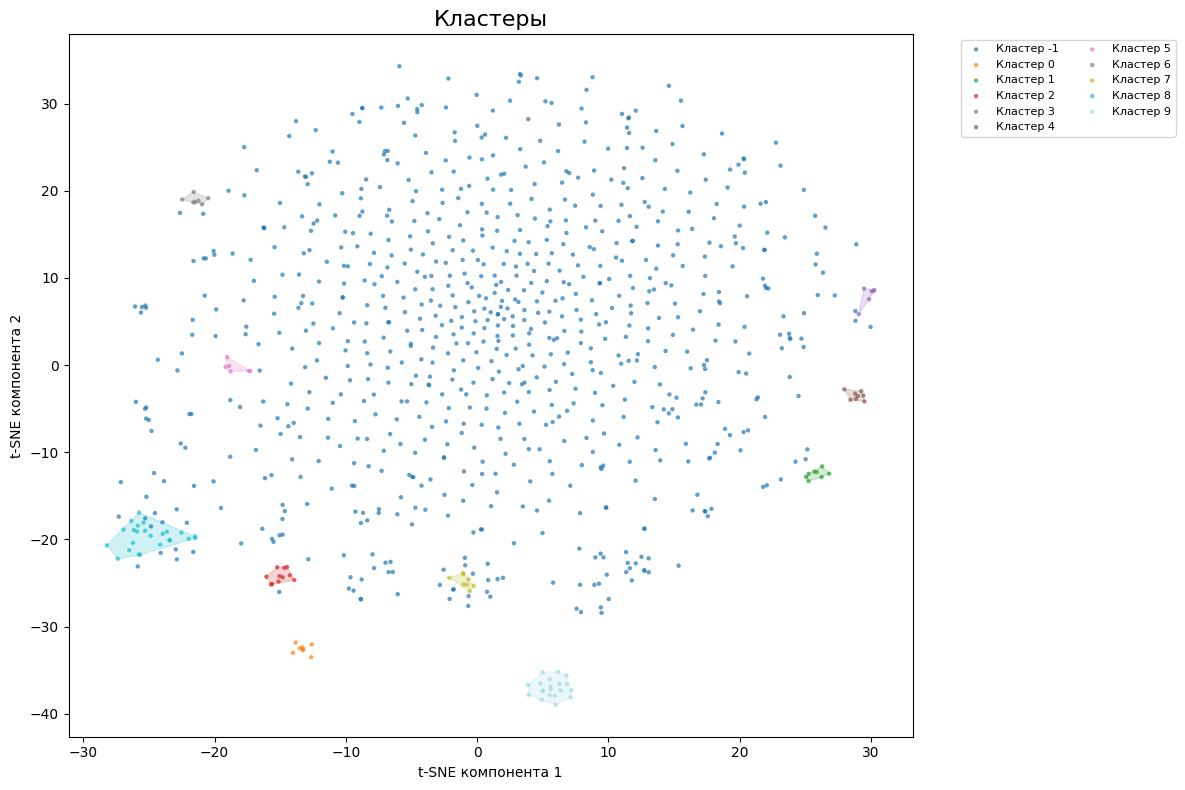

In [157]:
plot_clusters_2d(X_combined, clusters_dbscan_topic_extra, X_for_2d)

In [158]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_dbscan_topic_extra, X_combined),
    get_cluster_density(X_combined, clusters_dbscan_topic_extra)
)

Кластер 1 (плотность: 0.0005):
  0.0001: аделия петросян нанесла символический удар по мячу перед матчем спартака и акрона участница олимпиады появилась на поле в новой форме женской команды ...
  0.0002: вот такую офсайдную линию показали зрителям матча между оренбургом и акроном в моменте с отмененным голом артема дзюбы бездепозитный фрибет до новым к...
  0.0002: около болельщиков цска откликнулись на зов фанатского паблика и пришли на стадион чтобы расчистить его от снега уже на следующей неделе армейцы примут...

Кластер 2 (плотность: 0.0006):
  0.0000: британец льюис хэмилтон внезапно призвал освободить африку от британцев французов испанцев и португальцев в этом случае она станет величайшим местом в...
  0.0000: kitkat совместно с кадиллак сделали из шоколада болид новой команды ф в натуральную величину вес машины составил кг что эквивалентно батончикам у конд...
  0.0001: формула не успеет заменить гран при бахрейна и саудовской аравии из за конфликта на ближнем востоке в апрел

#### HDBSCAN

In [162]:
_ = not_grid_search(HDBSCAN, X_extra_scaled, min_cluster_size_list=np.arange(2, 15, 1))

min_cluster_size=2.0000 n_clusters=214.0000 silhouette_score=-0.1228 davies_bouldin_score=2.1960
min_cluster_size=3.0000 n_clusters=74.0000 silhouette_score=-0.0446 davies_bouldin_score=2.5569
min_cluster_size=4.0000 n_clusters=38.0000 silhouette_score=-0.0061 davies_bouldin_score=2.8596
min_cluster_size=5.0000 n_clusters=24.0000 silhouette_score=-0.0178 davies_bouldin_score=2.8891
min_cluster_size=6.0000 n_clusters=15.0000 silhouette_score=-0.0073 davies_bouldin_score=3.2490
min_cluster_size=7.0000 n_clusters=11.0000 silhouette_score=-0.0220 davies_bouldin_score=3.4416
min_cluster_size=8.0000 n_clusters=9.0000 silhouette_score=-0.0304 davies_bouldin_score=3.1252
min_cluster_size=9.0000 n_clusters=6.0000 silhouette_score=-0.0478 davies_bouldin_score=3.3514
min_cluster_size=10.0000 n_clusters=6.0000 silhouette_score=-0.0506 davies_bouldin_score=2.9509
min_cluster_size=11.0000 n_clusters=6.0000 silhouette_score=-0.0463 davies_bouldin_score=2.8201
min_cluster_size=12.0000 n_clusters=3.000

In [160]:
%%time
_ = not_grid_search(HDBSCAN, X_extra_norm, min_cluster_size_list=np.arange(2, 15, 2), metric='euclidean')

min_cluster_size=2.0000 n_clusters=206.0000 silhouette_score=-0.1250 davies_bouldin_score=1.6522
min_cluster_size=4.0000 n_clusters=2.0000 silhouette_score=0.5019 davies_bouldin_score=1.6833
min_cluster_size=6.0000 n_clusters=2.0000 silhouette_score=0.4954 davies_bouldin_score=1.5145
min_cluster_size=8.0000 n_clusters=2.0000 silhouette_score=0.3288 davies_bouldin_score=1.9204
CPU times: user 12.8 s, sys: 3.41 s, total: 16.2 s
Wall time: 12.6 s


HDBSCAN нашел 24 кластеров + шум


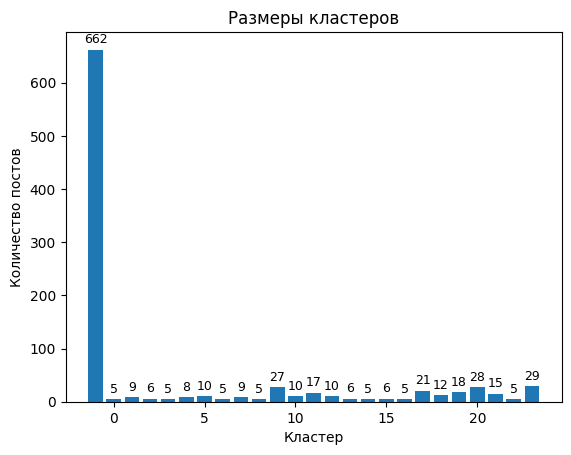

In [168]:
metric = 'cosine'
X_hdbscan = X_extra_scaled
min_cluster_size = 5

# metric = 'euclidean'
# X_hdbscan = X_extra_norm
# min_cluster_size = 2

hdbscan_topic_extra = HDBSCAN(min_cluster_size=min_cluster_size, metric=metric)
clusters_hdbscan_topic_extra = hdbscan_topic_extra.fit_predict(X_hdbscan)
n_clusters_hdbscan = len(set(clusters_hdbscan_topic_extra)) - (1 if -1 in clusters_hdbscan_topic_extra else 0)

print(f"HDBSCAN нашел {n_clusters_hdbscan} кластеров{' + шум' if -1 in clusters_hdbscan_topic_extra else ' без шума'}")

draw_cluster_sizes(clusters_hdbscan_topic_extra)

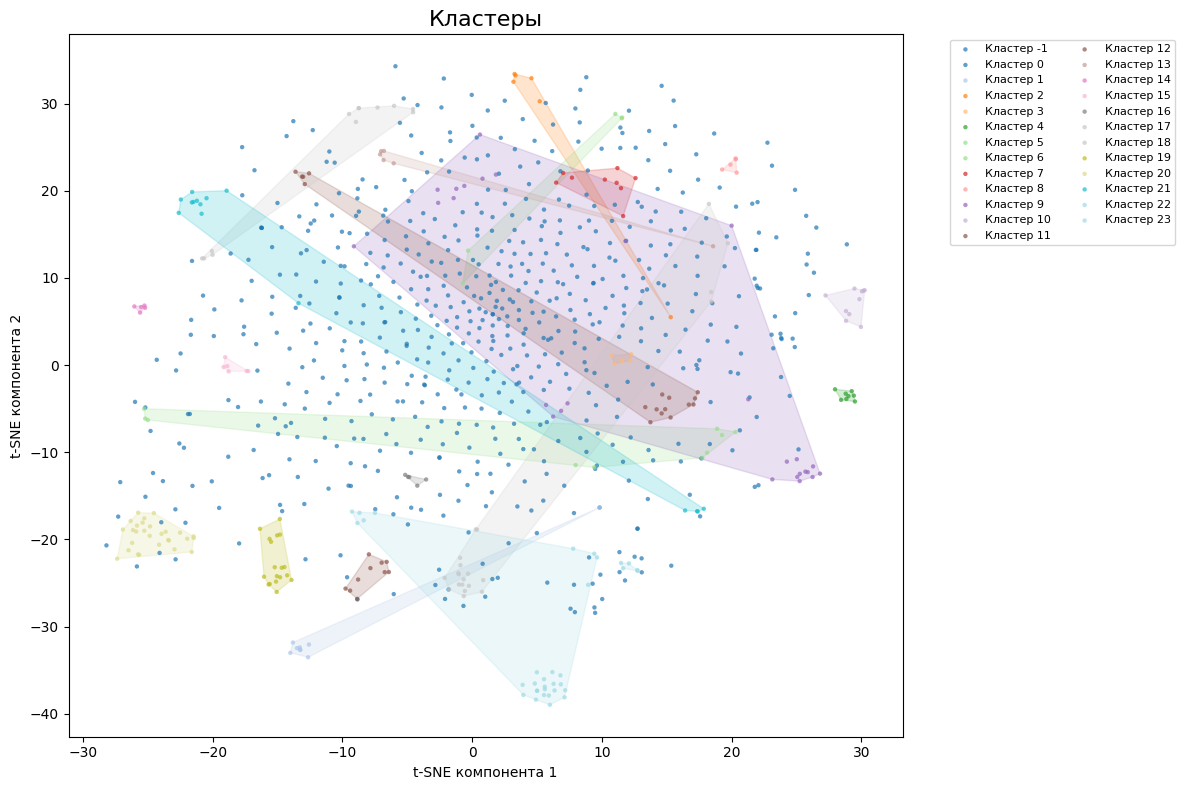

In [169]:
plot_clusters_2d(X_combined, clusters_hdbscan_topic_extra, X_for_2d)

In [165]:
print_top_of_clusters(
    get_top_texts_per_cluster(X_topic_data, clusters_hdbscan_topic_extra, X_combined),
    get_cluster_density(X_combined, clusters_hdbscan_topic_extra)
)

Кластер 27 (плотность: 0):
  0.0001: новая встреча сафонов vs головин и миланское дерби ждем роскошный футбол на этих выходных ставьте на топ матчи выходных с fonbet...
  0.0001: что смотрим на выходных сразу топ матча в италии сложный матч реала против набравшего форму сосьедада и барселону после разгрома от атлетико ставьте н...
  0.0001: два важнейших матча в апл на выходных отрыв арсенала от сити сократился до очков и может стать еще меньше если команда артеты проиграет в дерби сити в...

Кластер 36 (плотность: 0.0001):
  0.0000: разыгрываем комплектов лимитированного дропа новой коллекции winline с батраковым футболка худи кепка места с го по е получат классический монохромный...
  0.0001: разыгрываем роскошных приза для всех фанатов хоккея джерси сборной россии кепку с матча звезд кхл и футболка любого клуба fonbet кхл подпишитесь на сп...
  0.0001: вы дождались сегодня мы объявляем о запуске розыгрыша официального набора lego icons с ferrari f и михаэлем шумахером подпишитесь на

#### Спектральная кластеризация

In [186]:
n_samples = min(5000, X_combined.shape[0])
X_sample = X_combined[:n_samples]

pca = PCA(n_components=150, random_state=RANDOM_STATE)
X_reduced_extra = pca.fit_transform(X_sample)

print(f"После PCA: {X_reduced_extra.shape}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

После PCA: (938, 150)
Объясненная дисперсия: 100.00%


In [187]:
X_for_2d_extra_reduced = get_X_2d(X_reduced_extra)

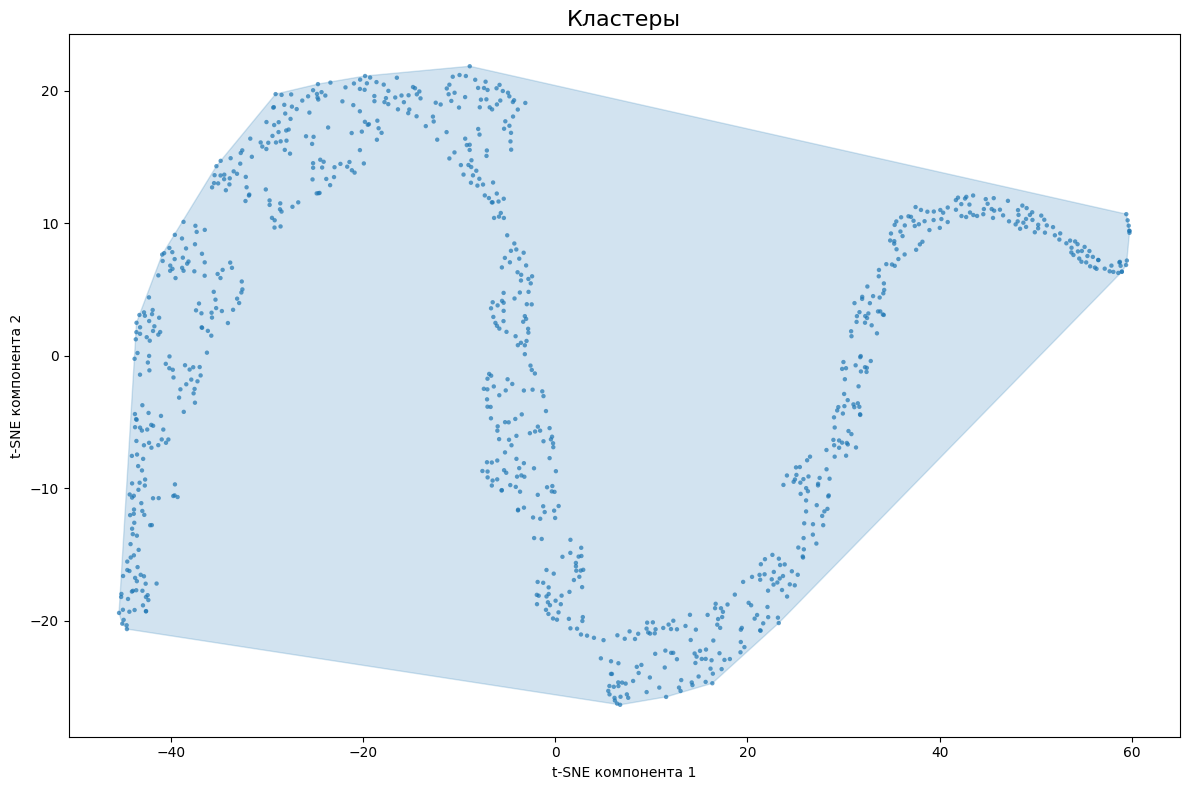

In [188]:
plot_clusters_2d(X_combined, zero_labels_combined, X_for_2d_extra_reduced, add_legend=False)

In [ ]:
%%time
_ = not_grid_search(SpectralClustering, X_reduced_extra, np.arange(2, 150, 8))

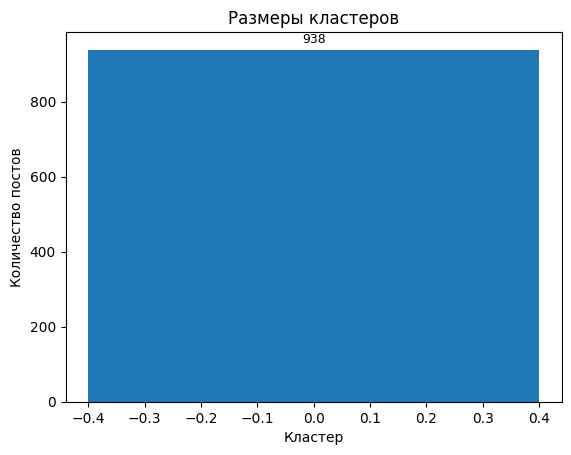

CPU times: user 27.1 s, sys: 17.3 s, total: 44.3 s
Wall time: 14.9 s


In [194]:
%%time
spectral_topic_extra = SpectralClustering(n_clusters=30, random_state=RANDOM_STATE)
clusters_spectral_topic_extra = spectral_topic.fit_predict(X_reduced_extra)

draw_cluster_sizes(clusters_spectral_topic_extra)

In [195]:
# plot_clusters_2d(X_reduced_extra, clusters_spectral_topic_extra, X_for_2d_extra_reduced, add_legend=False)

In [ ]:
# print_top_of_clusters(
#     get_top_texts_per_cluster(X_topic_data, clusters_spectral_topic_extra, X_combined),
#     get_cluster_density(X_combined, clusters_spectral_topic_extra)
# )

### Итоги

* Идея с тем, чтобы кластеризовать тексты внутри тематической группы, наверно, показала лучше результаты, чем были проведены ранее в других чекпоинтах. Так и будем делать далее.

* Однако над самой кластеризацией ещё следует поработать. Добавление некоторых признаков к данным ухудшило ситуацию: тексты стали хуже группироваться, даже топы текстов в каждой группе стали сильно отличаться друг от друга.

* В дальнейшем нужно попробовать применить другие алгоритмы векторизации текстов, основанные на нейронных сетях.

* Внимательно смотря на тексты, можно заметить, что не все посты являются полезными. Для данной агрегации постов лучше подходят новости, поскольку они в разных источниках имеют близкое друг к другу значение. Скорее всего в следующих этапах стоит научиться определять тип поста: новостной, рекламный и т.п.